<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-09-30 16:24:26--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  12.7MB/s    in 15s     

2026-09-30 16:24:41 (10.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


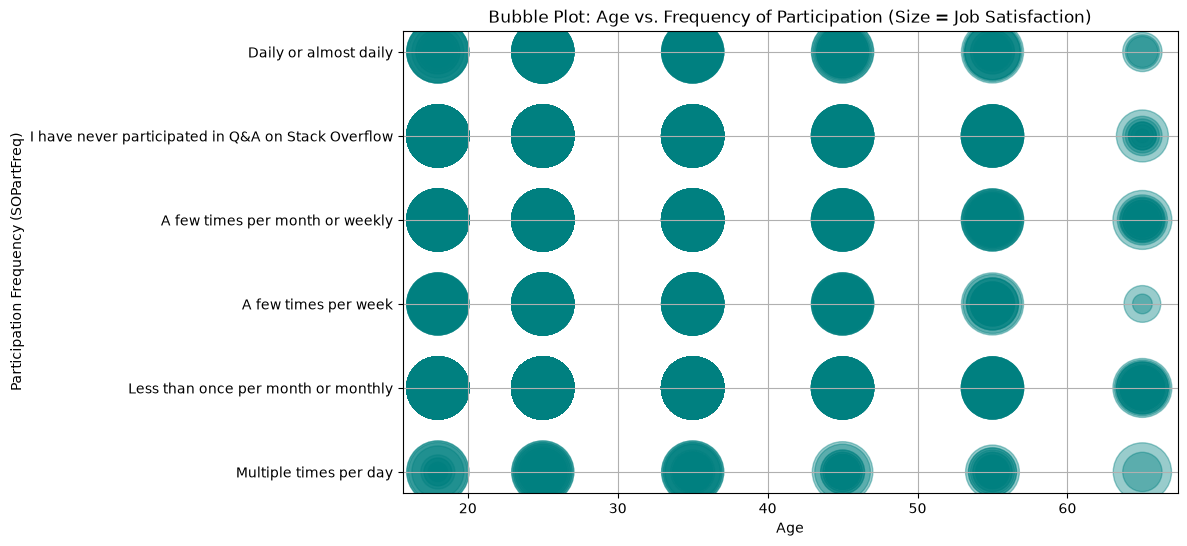

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir Age y JobSat a formato numérico
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['JobSat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce') if 'JobSatPoints_6' in df.columns else pd.to_numeric(df['JobSat'], errors='coerce')

# Filtrar nulos en las columnas involucradas
df_task1_1 = df[['Age_num', 'SOPartFreq', 'JobSat_num']].dropna()

# Crear la gráfica de burbujas
plt.figure(figsize=(10, 6))
plt.scatter(
    df_task1_1['Age_num'], 
    df_task1_1['SOPartFreq'], 
    s=df_task1_1['JobSat_num'] * 20, # Tamaño de burbuja según satisfacción laboral
    alpha=0.4, 
    c='teal'
)

plt.title('Bubble Plot: Age vs. Frequency of Participation (Size = Job Satisfaction)')
plt.xlabel('Age')
plt.ylabel('Participation Frequency (SOPartFreq)')
plt.grid(True)
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


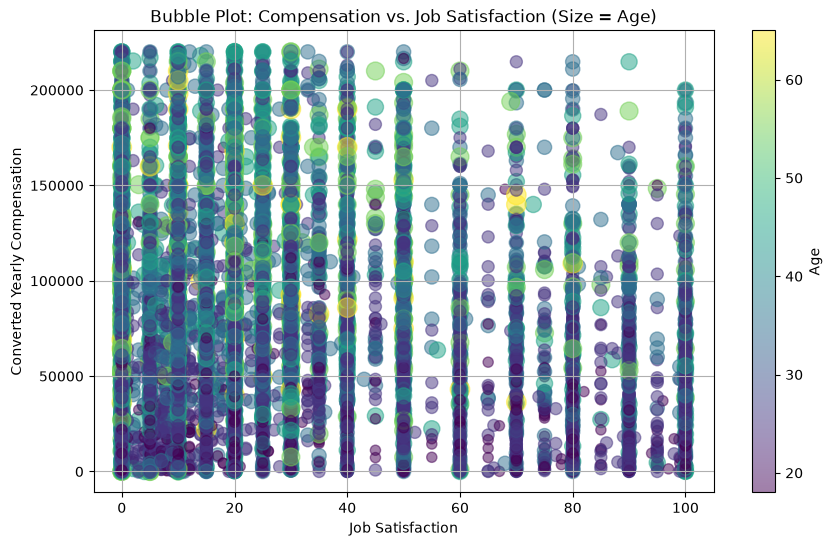

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir las variables a numéricas
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce') if 'JobSatPoints_6' in df.columns else pd.to_numeric(df['JobSat'], errors='coerce')
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Filtrar outliers de compensación para visualizar mejor
Q1 = df['ConvertedCompYearly_num'].quantile(0.25)
Q3 = df['ConvertedCompYearly_num'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['ConvertedCompYearly_num'] >= (Q1 - 1.5 * IQR)) & (df['ConvertedCompYearly_num'] <= (Q3 + 1.5 * IQR))]

df_task1_2 = df_filtered[['ConvertedCompYearly_num', 'JobSat_num', 'Age_num']].dropna()

# Crear la gráfica de burbujas
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_task1_2['JobSat_num'], 
    df_task1_2['ConvertedCompYearly_num'], 
    s=df_task1_2['Age_num'] * 3, # Tamaño de burbuja según la edad
    c=df_task1_2['Age_num'], 
    cmap='viridis', 
    alpha=0.5
)

plt.title('Bubble Plot: Compensation vs. Job Satisfaction (Size = Age)')
plt.xlabel('Job Satisfaction')
plt.ylabel('Converted Yearly Compensation')
plt.colorbar(scatter, label='Age')
plt.grid(True)
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



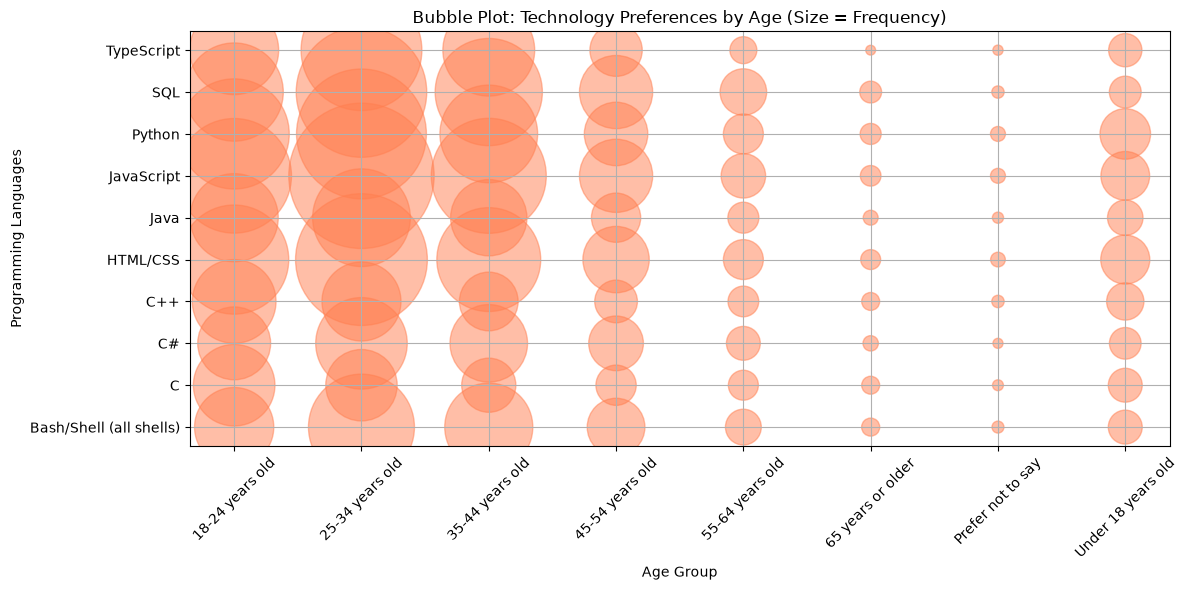

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Preparar datos: separar lenguajes y extraer edad numérica
df_lang = df[['LanguageHaveWorkedWith', 'Age']].dropna().copy()
df_lang['Language'] = df_lang['LanguageHaveWorkedWith'].astype(str).str.split(';')
df_exploded = df_lang.explode('Language')

# Contar la frecuencia de cada lenguaje por grupo/rango de edad
lang_counts = df_exploded.groupby(['Language', 'Age']).size().reset_index(name='Frequency')

# Filtrar los Top 10 lenguajes más populares para mayor claridad
top_10_langs = df_exploded['Language'].value_counts().head(10).index
lang_counts_top = lang_counts[lang_counts['Language'].isin(top_10_langs)]

# Graficar
plt.figure(figsize=(12, 6))
plt.scatter(
    lang_counts_top['Age'], 
    lang_counts_top['Language'], 
    s=lang_counts_top['Frequency'] * 0.8, # Tamaño proporcional a la frecuencia del lenguaje
    alpha=0.5, 
    c='coral'
)

plt.title('Bubble Plot: Technology Preferences by Age (Size = Frequency)')
plt.xlabel('Age Group')
plt.ylabel('Programming Languages')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


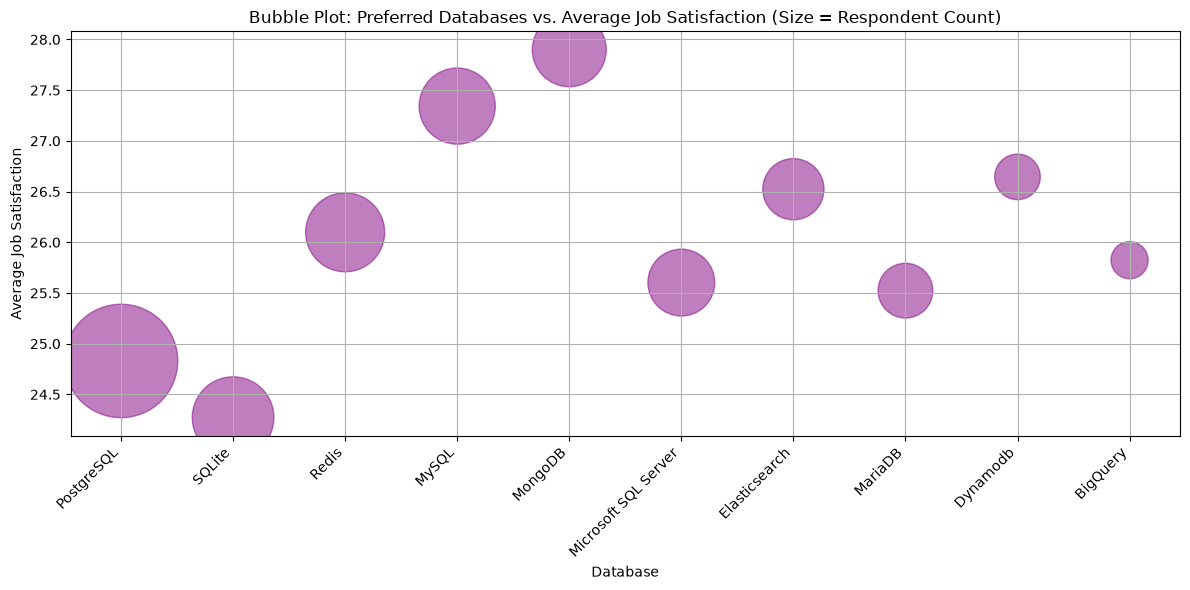

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir satisfacción a formato numérico
df['JobSat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce') if 'JobSatPoints_6' in df.columns else pd.to_numeric(df['JobSat'], errors='coerce')

# Separar bases de datos y limpiar nulos
df_db = df[['DatabaseWantToWorkWith', 'JobSat_num']].dropna().copy()
df_db['Database'] = df_db['DatabaseWantToWorkWith'].astype(str).str.split(';')
df_exploded_db = df_db.explode('Database')

# Calcular la satisfacción promedio y el conteo de encuestados por base de datos
db_summary = df_exploded_db.groupby('Database').agg(
    Avg_JobSat=('JobSat_num', 'mean'),
    Respondent_Count=('JobSat_num', 'count')
).reset_index()

# Filtrar las 10 bases de datos más populares para mantener la claridad
top_10_db = db_summary.sort_values(by='Respondent_Count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.scatter(
    top_10_db['Database'], 
    top_10_db['Avg_JobSat'], 
    s=top_10_db['Respondent_Count'] * 0.5,  # Tamaño de la burbuja = número de encuestados
    alpha=0.5, 
    color='purple'
)

plt.title('Bubble Plot: Preferred Databases vs. Average Job Satisfaction (Size = Respondent Count)')
plt.xlabel('Database')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


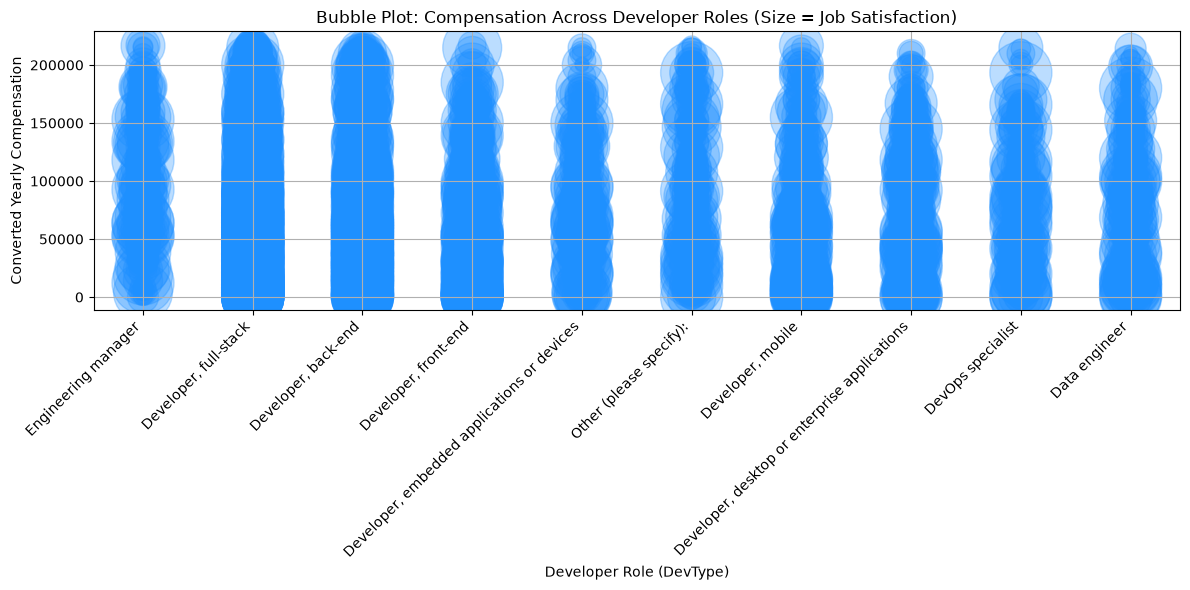

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir variables a numéricas
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce') if 'JobSatPoints_6' in df.columns else pd.to_numeric(df['JobSat'], errors='coerce')

# Separar los roles de desarrollador (DevType)
df_dev = df[['DevType', 'ConvertedCompYearly_num', 'JobSat_num']].dropna().copy()
df_dev['Role'] = df_dev['DevType'].astype(str).str.split(';')
df_exploded_dev = df_dev.explode('Role')

# Filtrar outliers de compensación para mejor escala
Q1 = df_exploded_dev['ConvertedCompYearly_num'].quantile(0.25)
Q3 = df_exploded_dev['ConvertedCompYearly_num'].quantile(0.75)
IQR = Q3 - Q1
df_dev_filtered = df_exploded_dev[
    (df_exploded_dev['ConvertedCompYearly_num'] >= (Q1 - 1.5 * IQR)) & 
    (df_exploded_dev['ConvertedCompYearly_num'] <= (Q3 + 1.5 * IQR))
]

# Seleccionar los 10 roles más comunes
top_roles = df_dev_filtered['Role'].value_counts().head(10).index
df_top_dev = df_dev_filtered[df_dev_filtered['Role'].isin(top_roles)]

plt.figure(figsize=(12, 6))
plt.scatter(
    df_top_dev['Role'], 
    df_top_dev['ConvertedCompYearly_num'], 
    s=df_top_dev['JobSat_num'] * 20,  # Tamaño de burbuja = satisfacción laboral
    alpha=0.3, 
    color='dodgerblue'
)

plt.title('Bubble Plot: Compensation Across Developer Roles (Size = Job Satisfaction)')
plt.xlabel('Developer Role (DevType)')
plt.ylabel('Converted Yearly Compensation')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


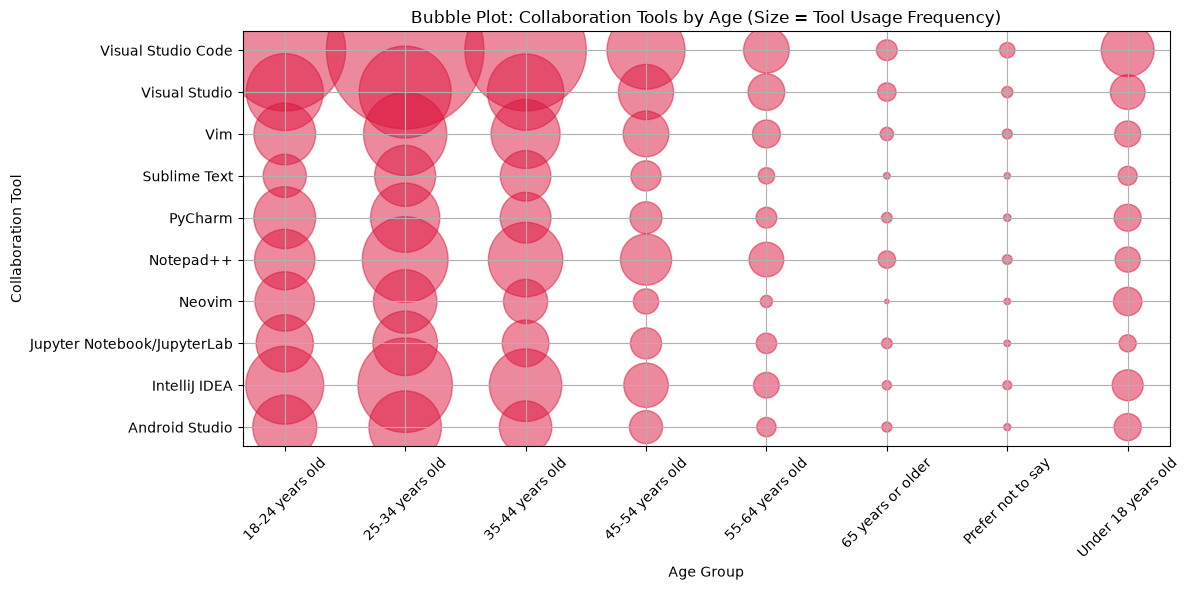

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Identificar la columna de herramientas de colaboración adecuada
collab_col = 'NEWCollabToolsHaveWorkedWith' if 'NEWCollabToolsHaveWorkedWith' in df.columns else 'CollabToolsHaveWorkedWith'

# Separar herramientas y limpiar nulos con edad
df_collab = df[[collab_col, 'Age']].dropna().copy()
df_collab['Tool'] = df_collab[collab_col].astype(str).str.split(';')
df_exploded_collab = df_collab.explode('Tool')

# Contar frecuencia por combinación de herramienta y edad
tool_counts = df_exploded_collab.groupby(['Tool', 'Age']).size().reset_index(name='Frequency')

# Filtrar las 10 herramientas de colaboración más frecuentes
top_10_tools = df_exploded_collab['Tool'].value_counts().head(10).index
tool_counts_top = tool_counts[tool_counts['Tool'].isin(top_10_tools)]

plt.figure(figsize=(12, 6))
plt.scatter(
    tool_counts_top['Age'], 
    tool_counts_top['Tool'], 
    s=tool_counts_top['Frequency'] * 0.8,  # Tamaño de burbuja = frecuencia de uso
    alpha=0.5, 
    color='crimson'
)

plt.title('Bubble Plot: Collaboration Tools by Age (Size = Tool Usage Frequency)')
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



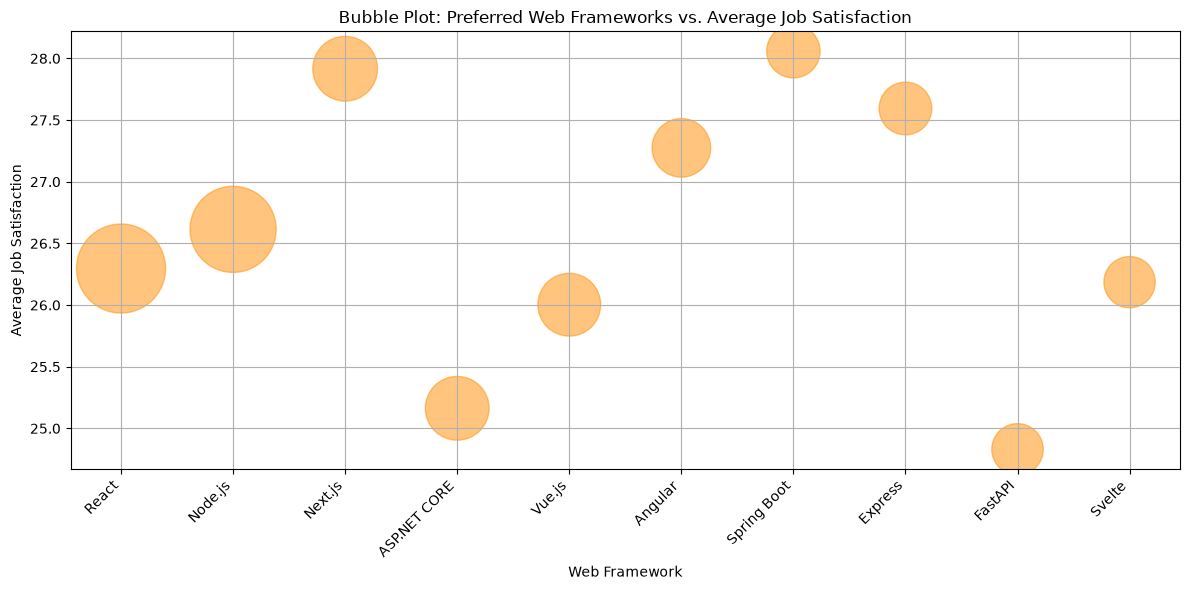

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identificar la columna del framework web y convertir satisfacción a numérico
framework_col = 'WebframeWantToWorkWith' if 'WebframeWantToWorkWith' in df.columns else 'WebframeWantToWorkWith'
df['JobSat_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce') if 'JobSatPoints_6' in df.columns else pd.to_numeric(df['JobSat'], errors='coerce')

# 2. Separar frameworks y limpiar nulos
df_fw = df[[framework_col, 'JobSat_num']].dropna().copy()
df_fw['Framework'] = df_fw[framework_col].astype(str).str.split(';')
df_exploded_fw = df_fw.explode('Framework')

# 3. Agrupar para obtener satisfacción promedio y número de encuestados por framework
fw_summary = df_exploded_fw.groupby('Framework').agg(
    Avg_JobSat=('JobSat_num', 'mean'),
    Respondent_Count=('JobSat_num', 'count')
).reset_index()

# 4. Seleccionar los 10 frameworks más populares
top_10_fw = fw_summary.sort_values(by='Respondent_Count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.scatter(
    top_10_fw['Framework'], 
    top_10_fw['Avg_JobSat'], 
    s=top_10_fw['Respondent_Count'] * 0.5,  # Tamaño de la burbuja = número de encuestados
    alpha=0.5, 
    color='darkorange'
)

plt.title('Bubble Plot: Preferred Web Frameworks vs. Average Job Satisfaction')
plt.xlabel('Web Framework')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



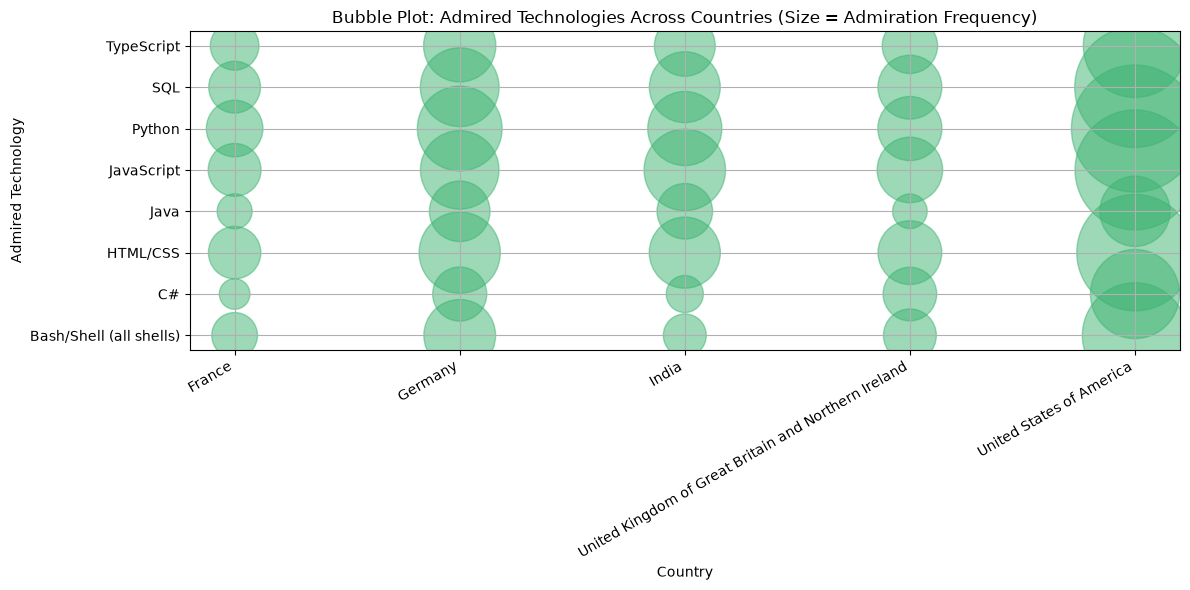

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identificar la columna de tecnología admirada (usar LanguageAdmired o LanguageHaveWorkedWith como respaldo)
tech_col = 'LanguageAdmired' if 'LanguageAdmired' in df.columns else 'LanguageHaveWorkedWith'

# 2. Separar tecnologías y limpiar nulos con País
df_tech = df[[tech_col, 'Country']].dropna().copy()
df_tech['Tech'] = df_tech[tech_col].astype(str).str.split(';')
df_exploded_tech = df_tech.explode('Tech')

# 3. Filtrar para mostrar solo los 5 países y 8 tecnologías más comunes para mayor legibilidad
top_countries = df_exploded_tech['Country'].value_counts().head(5).index
top_techs = df_exploded_tech['Tech'].value_counts().head(8).index

df_filtered_tech = df_exploded_tech[
    df_exploded_tech['Country'].isin(top_countries) & 
    df_exploded_tech['Tech'].isin(top_techs)
]

# 4. Calcular la frecuencia de admiración
tech_counts = df_filtered_tech.groupby(['Country', 'Tech']).size().reset_index(name='Frequency')

plt.figure(figsize=(12, 6))
plt.scatter(
    tech_counts['Country'], 
    tech_counts['Tech'], 
    s=tech_counts['Frequency'] * 2,  # Tamaño de la burbuja = frecuencia de admiración
    alpha=0.5, 
    color='mediumseagreen'
)

plt.title('Bubble Plot: Admired Technologies Across Countries (Size = Admiration Frequency)')
plt.xlabel('Country')
plt.ylabel('Admired Technology')
plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
